In [2]:
import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.transformations import NoJump
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import mdtraj as mdtraj

In [3]:
## Convert ase trajectory
! rm ../output/2l_wat_grace_small_a_wpS/wat_300_nvt.pdb
! rm ../output/2l_wat_grace_small_b_off/wat_300_nvt.pdb
! rm ../output/2l_wat_grace_medium_b_off/wat_300_nvt.pdb
! rm ../output/2l_wat_grace_medium_a_wpS/wat_300_nvt.pdb
! ase convert ../output/2l_wat_grace_small_a_wpS/wat_300_nvt.traj ../output/2l_wat_grace_small_a_wpS/wat_300_nvt.pdb
! ase convert ../output/2l_wat_grace_small_b_off/wat_300_nvt.traj ../output/2l_wat_grace_small_b_off/wat_300_nvt.pdb
! ase convert ../output/2l_wat_grace_medium_b_off/wat_300_nvt.traj ../output/2l_wat_grace_medium_b_off/wat_300_nvt.pdb
! ase convert ../output/2l_wat_grace_medium_a_wpS/wat_300_nvt.traj ../output/2l_wat_grace_medium_a_wpS/wat_300_nvt.pdb

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
100%|██████████| 1716/1716 [00:08<00:00, 194.62it/s]


Self Diffusion: 0.24013644270881665 A^2/ps
Self Diffusion: 2.4013644270881664e-09 m^2/s


100%|██████████| 1716/1716 [00:08<00:00, 195.29it/s]


Self Diffusion: 0.239273397363067 A^2/ps
Self Diffusion: 2.39273397363067e-09 m^2/s


100%|██████████| 1716/1716 [00:08<00:00, 200.67it/s]


Self Diffusion: 0.16393660320847628 A^2/ps
Self Diffusion: 1.6393660320847627e-09 m^2/s


100%|██████████| 1716/1716 [00:08<00:00, 198.10it/s]


Self Diffusion: 0.2323012784231253 A^2/ps
Self Diffusion: 2.3230127842312532e-09 m^2/s


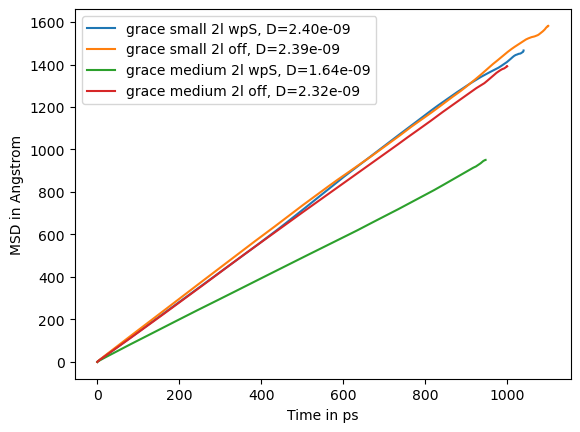

In [4]:
traj = {
    "grace small 2l wpS": "../output/2l_wat_grace_small_a_wpS/wat_300_nvt.pdb",
    "grace small 2l off": "../output/2l_wat_grace_small_b_off/wat_300_nvt.pdb",
    "grace medium 2l wpS": "../output/2l_wat_grace_medium_a_wpS/wat_300_nvt.pdb",
    "grace medium 2l off": "../output/2l_wat_grace_medium_b_off/wat_300_nvt.pdb",
}
for model, path in traj.items():
    universe = mda.Universe(path)
    atoms = universe.atoms
    transform = NoJump(atoms)
    universe.trajectory.add_transformations(transform)
    MSD_mm = msd.EinsteinMSD(universe, select="all", msd_type="xyz", fft=True)
    MSD_mm.run(step=1)

    result_mm = MSD_mm.results.timeseries
    msd_all = result_mm
    nframes = MSD_mm.n_frames
    timestep = 0.05  # in ps,  this needs to be the actual time between frames
    lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
    lag = lagtimes
    # plot the actual MSD
    # plt.show()

    # linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
    linear_model = linregress(lagtimes, result_mm)
    slope = linear_model.slope
    error = linear_model.stderr
    D = slope / 6
    print(f"Self Diffusion: {D} A^2/ps")
    print(f"Self Diffusion: {D*10**-8} m^2/s")
    diffusion = D * 10**-8
    plt.plot(
        lagtimes,
        result_mm,
        label=f'{model.split("/")[-1].split(".")[0]}, D={diffusion:.2e}',
    )
    plt.ylabel("MSD in Angstrom")
    plt.xlabel("Time in ps")

    # ANI diffusion
plt.legend()
plt.show()

# MACE: 2.51*10^-9 m^2/s